<a name='T'>

<p style="padding: 20px;
          background-color: black;
          font-family: computermodern;
          color: white;
          font-size: 200%;
          text-align: center;
          border-radius: 40px 20px;
          ">Quantized Autoencoder (QAE) Intrusion Detection Systems (IDSs) for IoT Devices<br>
          </p>
<p style="font-family: computermodern;
          color: #000000;
          font-size: 175%;
          text-align: center;
          ">Created by Alexandre Le Mercier on the 9th of July 2024<br>
            Based on the paper of B. S. Sharmila and Rohini Nagapadma<br>
             </p>
    
    

![](https://www.googleapis.com/download/storage/v1/b/kaggle-forum-message-attachments/o/inbox%2F17037041%2F77a91655d5c74e8c7f00ad18ef156625%2Ffor%20kaggle.png?generation=1721041674229724&alt=media)
    
*Figure created by the author*: the main prinicple is to train a QAE (quantized autoencoder) on data containing only malicious traffic, so that if an input is considered as an anomaly (high reconstitution error like in the picture above),then we conclude that this is *not* an anomaly, thus a benigh internet traffic.

    
<a id="TOC"></a>

<div style="background-color: #e8f5e9; border-left: 10px solid #66bb6a; padding: 20px; margin-bottom: 20px; border-radius: 8px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <h1 style="color: #388e3c;">Table of Contents</h1>
    <ul style="list-style-type: none;">
        <li><a href="#s1" style="color: #2e7d32;"><strong>Main Steps</strong></a></li>
        <li><a href="#s0" style="color: #2e7d32;"><strong>Imports and Constants</strong></a></li>
        <li><a href="#s2" style="color: #2e7d32;"><strong>What is an Autoencoder?</strong></a>
        <li><a href="#s3" style="color: #2e7d32;"><strong>What is Quantization and How Does It Work?</strong></a>
        <br>
        <li><a href="#s4" style="color: #2e7d32;"><strong>1. Data Analysis (EDA made by J. Arvidsson)</strong></a>
        <li><a href="#s5" style="color: #2e7d32;"><strong>2. Building the Article's Autoencoder</strong></a>
        <li><a href="#s6" style="color: #2e7d32;"><strong>3. Quantization</strong></a>
        <li><a href="#s7" style="color: #2e7d32;"><strong>4. Building the QAE Class</strong></a>
        <li><a href="#s8" style="color: #2e7d32;"><strong>5. Test the QAE Class on the CICIoT23 Dataset</strong></a>
        <li><a href="#s9" style="color: #2e7d32;"><strong>6. Comparison with Random Forest Model</strong></a>
      
</div>


**Link to the open-access article**: [Quantized autoencoder (QAE) intrusion detection system for anomaly detection in resource-constrained IoT devices using RT-IoT2022 dataset](https://cybersecurity.springeropen.com/counter/pdf/10.1186/s42400-023-00178-5.pdf)
    
**Link to the RT-IoT2022 dataset**: [Cyber Attacks on Real-Time Internet of Things](https://www.kaggle.com/datasets/joebeachcapital/real-time-internet-of-things-rt-iot2022)
    
**Link to the original EDA analysis made by Joakim Arvidsson:** [CyberAttacks RT-IoT2022 | EDA Starter](https://www.kaggle.com/code/joebeachcapital/cyberattacks-rt-iot2022-eda-starter)

**Link to the autoencoding tutorial made by Oh Seok Kim:** [Dectecting Anomaly using Autoencoder!](https://www.kaggle.com/code/ohseokkim/dectecting-anomaly-using-autoencoder)

**Link to the Pytorch quantization tutorial made by Ali Abdinb:** [🔥How does quantization work?🚀](https://www.kaggle.com/code/aliabdin1/how-does-quantization-work)

**Link to the Tensorflow quantization tutorial made by Ritvik Rastogi**: [Model Quantization
](https://www.kaggle.com/code/ritvik1909/model-quantization)
    
**Link to the light CICIot2023 dataset creation notebook made by Madhav Malhotra**: [Creating a Smaller Dataset for CICIoT2023](https://www.kaggle.com/code/madhavmalhotra/creating-a-smaller-dataset-for-ciciot2023/notebook)

<a id="s1"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>Main Steps</h1>
</div>

[Back to table of contents](#TOC)

![](https://www.googleapis.com/download/storage/v1/b/kaggle-forum-message-attachments/o/inbox%2F17037041%2Fab5642b37831311be3b6ba3b663162e2%2F_article.png?generation=1721117897647721&alt=media)

<a id="s0"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>Imports and Constants</h1>
</div>

[Back to table of contents](#TOC)

<div style="color: black; background-color: #ffcccc; padding: 10px; border-left: 5px solid #ff3333; border-radius: 5px;">
    <strong>Important note:</strong> you need tensofrlow 2.13.0 in order to be compatible with tensorflow_model_optimization 0.8.0. Current version of tensorflow (2.17.0 currently) leads to compatibility issues regarding model pruning.
</div>

In [1]:
# Ensuring that you have the right version of tensorflow is very important here
!pip install tensorflow==2.13.0
!pip install tensorflow_model_optimization

  Obtaining dependency information for tensorflow_model_optimization from https://files.pythonhosted.org/packages/5a/a0/f38c9ce977285d3f347f6d64cf227924fe9fc97d780d6df4a55563e311af/tensorflow_model_optimization-0.8.0-py2.py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 2.1 MB/s eta 0:00:00a 0:00:01m


In [2]:
# Other useful imports
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install scikit-learn
!pip install pandas
!pip install tqdm

In [3]:
# Neural network's optimization
!pip install optuna

In [6]:
import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import warnings
from tqdm import tqdm, trange
import optuna

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import layers, regularizers, Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
import tensorflow_model_optimization as tfmot

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans

RANDOM_SEED = 5  # my favourite number
DATA_PATH = '/kaggle/input/real-time-internet-of-things-rt-iot2022/RT_IOT2022.csv'
#DATA_PATH = '../../rt-iot2022/RT_IOT2022.csv'
#DATA_PATH = 'RT_IOT2022.csv'
#LIGHT_CIC_PATH = '0.01percent_2classes.csv' # Light version of the CIC dataset
LIGHT_CIC_PATH = '/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.01percent_2classes.csv' # Light version of the CIC dataset
LIGHT_CIC_34_PATH = '/kaggle/input/creating-a-smaller-dataset-for-ciciot2023/0.01percent_34classes.csv'
FIG_PATH = ""
TARGET = 'Attack_type'
TARGET_CIC = 'benign'
LAYERS_1_AND_7_NEURONS = 128  # default is 128

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)
print("TensorFlow Model Optimization version:", tfmot.__version__)
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

assert tf.__version__ == "2.13.0", 'TensorFlow 2.13 required for compatibility with tfmot 0.8.0.'
assert LAYERS_1_AND_7_NEURONS % 16 == 0, 'The specified layer number is not dividable by 16.'

NumPy version: 1.24.3
TensorFlow version: 2.13.0
TensorFlow Model Optimization version: 0.8.0
Num GPUs Available:  2


<a id="s2"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>What Is An Autoencoder?</h1>
</div>

[Back to table of contents](#TOC)

*The following information comes from [Oh Seok Kim](https://www.kaggle.com/code/ohseokkim/dectecting-anomaly-using-autoencoder):*

## What is anomaly detection?

> Anomaly detection (aka outlier analysis) is a step in data mining that identifies data points, events, and/or observations that deviate from a dataset’s normal behavior. Anomalous data can indicate critical incidents, such as a technical glitch, or potential opportunities, for instance a change in consumer behavior. Machine learning is progressively being used to automate anomaly detection.

Ref: https://www.anodot.com/blog/what-is-anomaly-detection

## Autoencoder-based anomaly detection

> Autoencoder-based anomaly detection is to perform anomaly detection by compressing normal data into a latent space of a smaller dimension than the original data through the autoencoder, then restoring it and comparing the difference between the restored data and the original data. The part that encodes the normal data to the lower dimension is called the encoder, and the part that decodes the compressed sample back to the original dimension is called the decoder. The data expression in the latent space where the data is compressed by the encoder is called a latent variable. The autoencoder learns through the process of minimizing the difference between the original data and the restored data, and in the process, the features of the learning data are naturally extracted to construct a latent space.

> The specific way an autoencoder compares the input and output differences also determines the performance and characteristics of anomaly detection. The most basic method considers the original data and the restored data as points in the n-dimensional coordinate space, and uses the distance between the two points as an index of the input/output difference. This metric is called the reconstruction error. Since the autoencoder used for anomaly detection is trained to restore normal data well, compression and restoration cannot be performed effectively when abnormal data is input. Therefore, the abnormal data has a large restoration error.

> The restoration error can be used as one of the anomaly scores that indicate the degree of anomaly of a given data. If the anomaly score is greater than a predetermined threshold, the data is considered anomaly, and if it is small, it is considered normal. Thresholds are set differently depending on the specific characteristics and requirements of the anomaly detection you want to perform.

<a id="s3"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>What Is Quantization and How Does It Work?</h1>
</div>

[Back to table of contents](#TOC)

*The following information comes from [Ali Abdin](https://www.kaggle.com/code/aliabdin1/how-does-quantization-work):*

## Understanding and Applying Quantization

Quantization is a method that can allow models to run faster and use less memory. By converting 32-bit floating-point numbers (the float32 data type) into lower-precision formats, like 8-bit integers (the int8 data type), we can reduce the computational requirements of our models.

![](https://www.googleapis.com/download/storage/v1/b/kaggle-forum-message-attachments/o/inbox%2F17037041%2F099474c8df8a1d889515be9dd2fdec7b%2F_quantized.png?generation=1721120430703949&alt=media)

<a id="s4"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>1. Data Analysis (EDA Inspired By J. Arvidsson)</h1>
</div>

[Back to table of contents](#TOC)

In [5]:
df = pd.read_csv(DATA_PATH)
df.head()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


In [6]:
df.tail()

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
123112,2005,59247,63331,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123113,2006,59247,64623,tcp,-,0.000007,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123114,2007,59247,64680,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123115,2008,59247,65000,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN
123116,2009,59247,65129,tcp,-,0.000006,1,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1024,0,1024,NMAP_XMAS_TREE_SCAN


In [7]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [8]:
df.shape

(123117, 84)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 84 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id.orig_p                 123117 non-null  int64  
 1   id.resp_p                 123117 non-null  int64  
 2   proto                     123117 non-null  object 
 3   service                   123117 non-null  object 
 4   flow_duration             123117 non-null  float64
 5   fwd_pkts_tot              123117 non-null  int64  
 6   bwd_pkts_tot              123117 non-null  int64  
 7   fwd_data_pkts_tot         123117 non-null  int64  
 8   bwd_data_pkts_tot         123117 non-null  int64  
 9   fwd_pkts_per_sec          123117 non-null  float64
 10  bwd_pkts_per_sec          123117 non-null  float64
 11  flow_pkts_per_sec         123117 non-null  float64
 12  down_up_ratio             123117 non-null  float64
 13  fwd_header_size_tot       123117 non-null  i

In [10]:
df.nunique()

id.orig_p               65478
id.resp_p                1809
proto                       3
service                    10
flow_duration           16383
                        ...  
idle.std                 1001
fwd_init_window_size       20
bwd_init_window_size       56
fwd_last_window_size      109
Attack_type                12
Length: 84, dtype: int64

In [11]:
df.describe(include='all')

,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
count,123117.000000,123117.000000,123117,123117,123117.000000,123117.000000,123117.000000,123117.000000,123117.000000,1.231170e+05,...,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,1.231170e+05,123117.000000,123117.000000,123117.000000,123117
unique,NaN,NaN,3,10,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12
top,NaN,NaN,tcp,-,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DOS_SYN_Hping
freq,NaN,NaN,110427,102861,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94659
mean,34639.258738,1014.305092,NaN,NaN,3.809566,2.268826,1.909509,1.471218,0.820260,3.518063e+05,...,2.353599e+04,1.616655e+06,1.701956e+06,3.517644e+06,1.664985e+06,4.550183e+04,6118.905123,2739.776018,751.647514,NaN
std,19070.620354,5256.371994,NaN,NaN,130.005408,22.336565,33.018311,19.635196,32.293948,3.707645e+05,...,1.477935e+06,8.809396e+06,9.252337e+06,1.229508e+08,9.007064e+06,1.091361e+06,18716.313861,10018.848534,6310.183843,NaN
min,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,NaN
25%,17702.000000,21.000000,NaN,NaN,0.000001,1.000000,1.000000,1.000000,0.000000,7.454354e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000,NaN
50%,37221.000000,21.000000,NaN,NaN,0.000004,1.000000,1.000000,1.000000,0.000000,2.467238e+05,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000,NaN
75%,50971.000000,21.000000,NaN,NaN,0.000005,1.000000,1.000000,1.000000,0.000000,5.242880e+05,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,64.000000,0.000000,64.000000,NaN


In [12]:
df.isnull().sum()

id.orig_p               0
id.resp_p               0
proto                   0
service                 0
flow_duration           0
                       ..
idle.std                0
fwd_init_window_size    0
bwd_init_window_size    0
fwd_last_window_size    0
Attack_type             0
Length: 84, dtype: int64

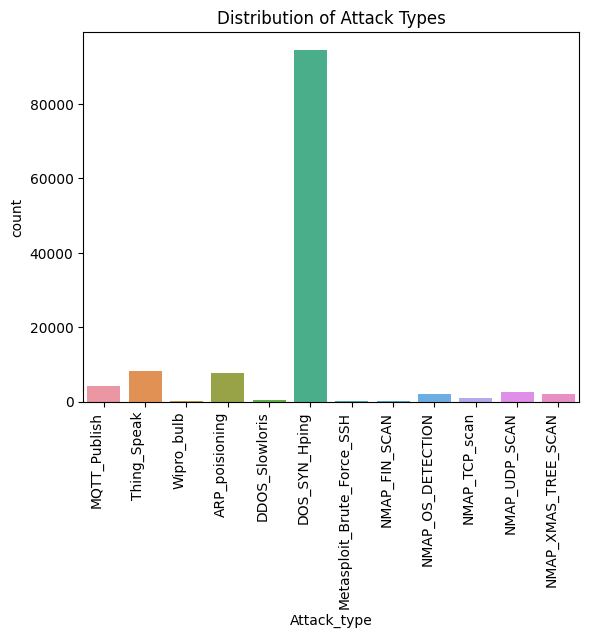

In [13]:
sns.countplot(x='Attack_type', data=df)
plt.title('Distribution of Attack Types')
plt.xticks(rotation=90, ha='right')
plt.show()

In [14]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

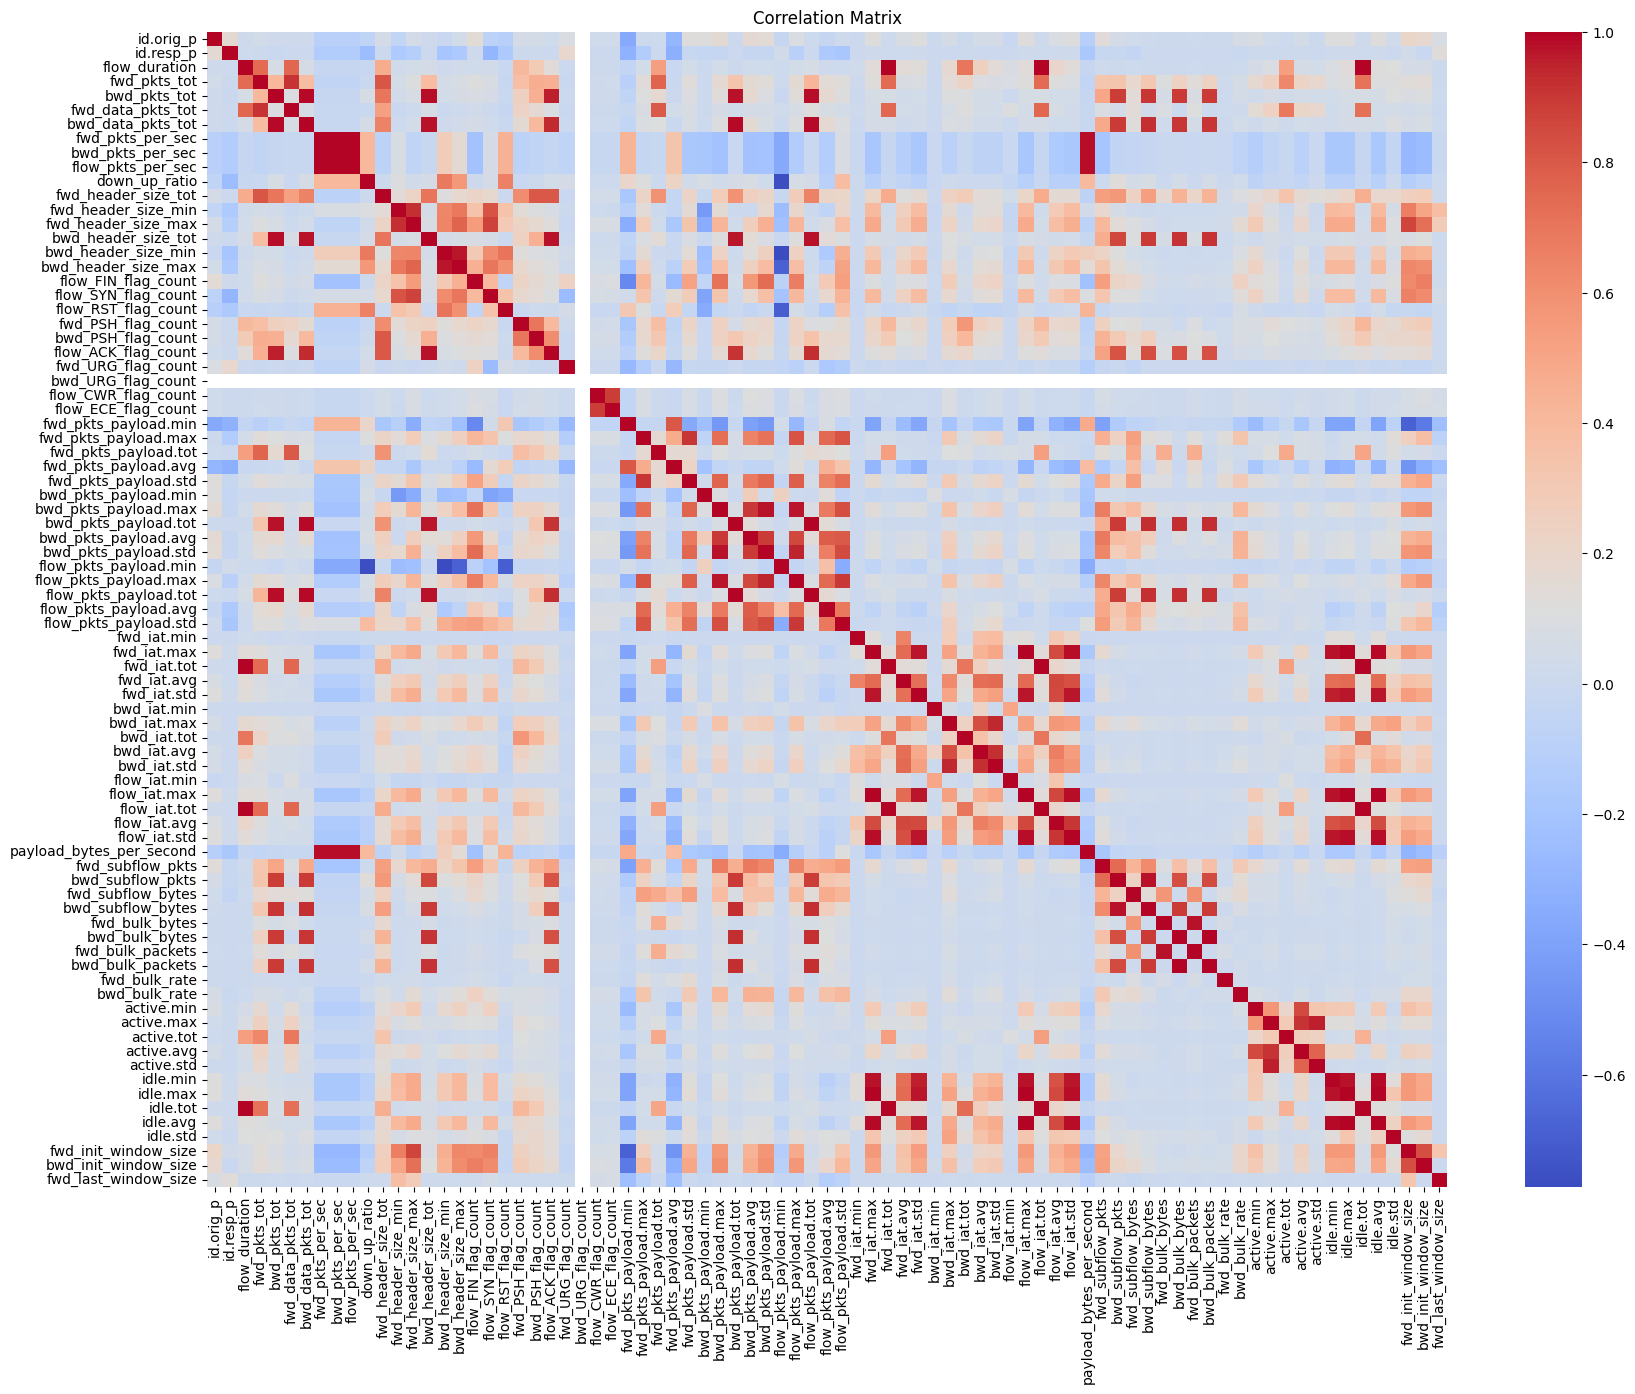

In [15]:
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig(FIG_PATH + "Correlation_Matrix.png")
plt.show()

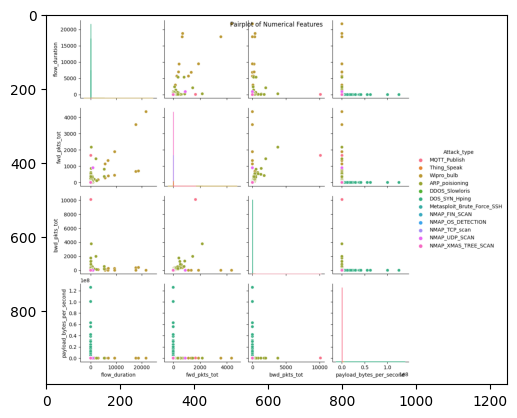

In [16]:
figure_file = os.path.join(FIG_PATH, "Pairplot.png")

# Check if the image already exists (takes a long time to compute)
if os.path.exists(figure_file):
    # Load and display the existing image
    img = Image.open(figure_file)
    plt.imshow(img)
else:
    # Create the pairplot
    sns.pairplot(df[['flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'payload_bytes_per_second', 'Attack_type']], hue='Attack_type')
    plt.suptitle('Pairplot of Numerical Features')
    # Save the figure
    plt.savefig(figure_file)
    # Display the plot
    plt.show()

<a id="s5"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>2. Building the Article's Autoencoder</h1>
</div>

[Back to table of contents](#TOC)
## 2.1 Additional Preprocessing

In [17]:
df_saved = df

In [18]:
# Handle categorical data using one-hot encoding
categorical_columns = ['proto', 'service']
encoder = OneHotEncoder(sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_columns])

# Create a DataFrame for the encoded categorical features
encoded_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_columns))

# Drop the original categorical columns and concatenate the encoded features
df = df.drop(categorical_columns, axis=1)
df = pd.concat([df, encoded_df], axis=1)

# Split into features and target
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_rt, y_rt = X_scaled, y # save for later

## 2.2 Building the Autoencoder

In [19]:
# Split the dataset into training, validation, and test sets (70% train, 15% validation, 15% test)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.3, random_state=RANDOM_SEED)

# Define the autoencoder model using Sequential API
input_dim = X_train.shape[1]

autoencoder = tf.keras.models.Sequential([
    layers.Dense(LAYERS_1_AND_7_NEURONS, activation='relu', input_shape=(input_dim,)),
    layers.Dense(LAYERS_1_AND_7_NEURONS//2, activation='relu'),
    layers.Dense(LAYERS_1_AND_7_NEURONS//4, activation='relu'),
    layers.Dense(LAYERS_1_AND_7_NEURONS//8, activation='relu'),
    layers.Dense(LAYERS_1_AND_7_NEURONS//4, activation='relu'),
    layers.Dense(LAYERS_1_AND_7_NEURONS//2, activation='relu'),
    layers.Dense(LAYERS_1_AND_7_NEURONS, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')
])

autoencoder.compile(optimizer='adam', loss='mean_squared_error')

autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               12160     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 16)                528       
                                                                 
 dense_4 (Dense)             (None, 32)                544       
                                                                 
 dense_5 (Dense)             (None, 64)                2112      
                                                                 
 dense_6 (Dense)             (None, 128)               8

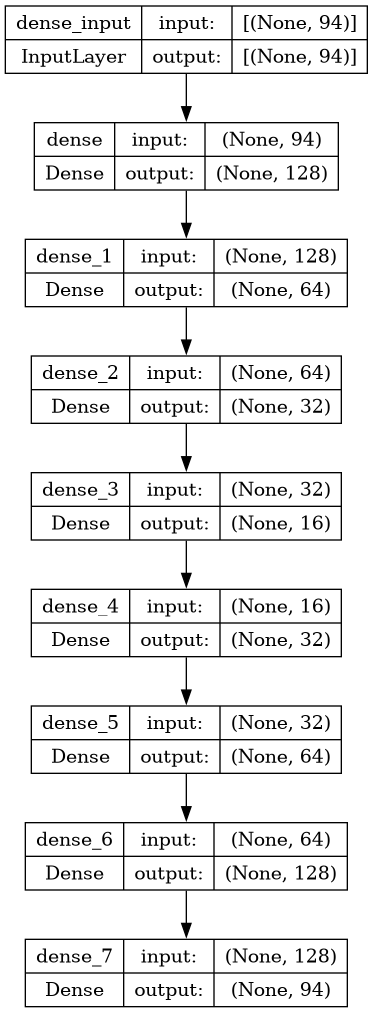

In [20]:
# Generate a visual representation of the model
plot_model(autoencoder, to_file='autoencoder_model.png', show_shapes=True, show_layer_names=True)

*Side note*: The primary purpose of an autoencoder, including the Quantized Autoencoder (QAE) described in the article, is to learn a compressed representation of the input data and reconstruct it. This means that it is **not** directly designed for classification tasks, such as predicting the output class (attack type). Therefore, the input data and the target data for the autoencoder are **the same**.

## 2.3 Comparison with a DNN Classifier

The idea is to understand that a classical DNN classifier would be much heavier than an autoencoder for a similar anomaly detection efficiency.

In [21]:
# Define the regular dense deep learning model
model_dense = tf.keras.models.Sequential([
    Dense(LAYERS_1_AND_7_NEURONS*2, activation='relu', input_shape=(X_scaled.shape[1],)),
    Dense(LAYERS_1_AND_7_NEURONS, activation='relu'),
    Dense(LAYERS_1_AND_7_NEURONS//2, activation='relu'),
    Dense(LAYERS_1_AND_7_NEURONS//4, activation='relu'),
    Dense(LAYERS_1_AND_7_NEURONS//16, activation='relu'),
    Dense(1, activation='sigmoid')  # Assuming binary classification for threat detection
])

# Compile the model
model_dense.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model_dense.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 256)               24320     
                                                                 
 dense_9 (Dense)             (None, 128)               32896     
                                                                 
 dense_10 (Dense)            (None, 64)                8256      
                                                                 
 dense_11 (Dense)            (None, 32)                2080      
                                                                 
 dense_12 (Dense)            (None, 8)                 264       
                                                                 
 dense_13 (Dense)            (None, 1)                 9         
                                                                 
Total params: 67825 (264.94 KB)
Trainable params: 6782

## 2.4 Train the Autoencoder

In [22]:
# Train the autoencoder
history = autoencoder.fit(X_train, X_train, 
                          epochs=50, 
                          batch_size=32, 
                          shuffle=True, 
                          validation_data=(X_val, X_val))

Epoch 1/50
2694/2694 [==============================] - 16s 5ms/step - loss: 0.8670 - val_loss: 0.7485
Epoch 2/50
2694/2694 [==============================] - 13s 5ms/step - loss: 0.8498 - val_loss: 0.7470
Epoch 3/50
2694/2694 [==============================] - 12s 4ms/step - loss: 0.8489 - val_loss: 0.7470
Epoch 4/50
2694/2694 [==============================] - 12s 4ms/step - loss: 0.8489 - val_loss: 0.7465
Epoch 5/50
2694/2694 [==============================] - 12s 4ms/step - loss: 0.8487 - val_loss: 0.7466
Epoch 6/50
2694/2694 [==============================] - 12s 4ms/step - loss: 0.8484 - val_loss: 0.7469
Epoch 7/50
2694/2694 [==============================] - 12s 5ms/step - loss: 0.8487 - val_loss: 0.7467
Epoch 8/50
2694/2694 [==============================] - 12s 4ms/step - loss: 0.8482 - val_loss: 0.7461
Epoch 9/50
2694/2694 [==============================] - 12s 4ms/step - loss: 0.8476 - val_loss: 0.7454
Epoch 10/50
2694/2694 [==============================] - 12s 4ms/step - l

## 2.5 History Analysis

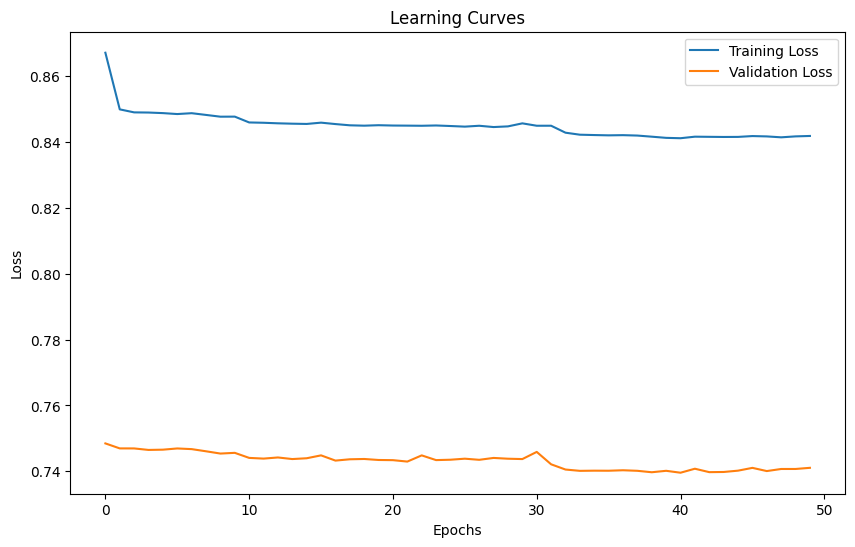

In [23]:
# Plot the learning curves
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(FIG_PATH + "Learning_curves.png")
plt.show()

<a id="s6"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>3. Quantization</h1>
</div>

[Back to table of contents](#TOC)

## 3.1 Save and Convert to TFL Light


In [24]:
# Save the autoencoder model
autoencoder.save('autoencoder_model.h5')

# Load the model (just to ensure the saving part is working)
model = tf.keras.models.load_model('autoencoder_model.h5')

# Convert the model to TFLite format
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
with open('autoencoder_model.tflite', 'wb') as f:
    f.write(tflite_model)

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## 3.2 Quantize Parameters and Activation Functions

In [25]:
def representative_data_gen():
    for input_value in tf.data.Dataset.from_tensor_slices(X_train).batch(1).take(100):
        yield [tf.cast(input_value, tf.float32)]

def quantize_parameters_and_activation_functions(model, name="autoencoder_int_quant_model"):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_data_gen
    # Ensure that if any ops can't be quantized, the converter throws an error
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # Set the input and output tensors to uint8 
    converter.inference_input_type = tf.uint8
    converter.inference_output_type = tf.uint8
    
    tflite_int_quant_model = converter.convert()
    
    # Save the quantized model
    with open(name + '.tflite', 'wb') as f:
        f.write(tflite_int_quant_model)
        
quantize_parameters_and_activation_functions(model)

/opt/conda/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


## 3.3 Pruning and Weight Clustering

In [26]:
# Define the pruning parameters
pruning_params = {
    'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.2,
        final_sparsity=0.8,
        begin_step=0,
        end_step=len(X_train) // 32 * 10
    )
}

config = autoencoder.get_config()
weights = autoencoder.get_weights()

# Reinitialize the autoencoder as a keras.models.Sequential
autoencoder = keras.models.Sequential.from_config(config)
autoencoder.set_weights(weights)

# Verify the type and other details
print(autoencoder)
print(autoencoder.dtype)
print(type(autoencoder))

# Apply pruning to the Sequential model
pruned_model = tfmot.sparsity.keras.prune_low_magnitude(autoencoder, **pruning_params)

# Compile the pruned model
pruned_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the pruned model
callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]

pruned_model.fit(X_train, X_train,
                 epochs=10,
                 batch_size=32,
                 validation_data=(X_val, X_val),
                 callbacks=callbacks)

# Strip the pruning wrappers
model_for_export = tfmot.sparsity.keras.strip_pruning(pruned_model)

# Save the pruned model
model_for_export.save('pruned_autoencoder_model.h5')

quantize_parameters_and_activation_functions(model_for_export, "autoencoder_pruned_model")

float32
<class 'keras.src.engine.sequential.Sequential'>
Epoch 1/10
2694/2694 [==============================] - 29s 8ms/step - loss: 0.8418 - val_loss: 0.7416
Epoch 2/10
2694/2694 [==============================] - 20s 7ms/step - loss: 0.8425 - val_loss: 0.7409
Epoch 3/10
2694/2694 [==============================] - 20s 7ms/step - loss: 0.8429 - val_loss: 0.7419
Epoch 4/10
2694/2694 [==============================] - 20s 7ms/step - loss: 0.8433 - val_loss: 0.7417
Epoch 5/10
2694/2694 [==============================] - 20s 7ms/step - loss: 0.8439 - val_loss: 0.7420
Epoch 6/10
2694/2694 [==============================] - 20s 7ms/step - loss: 0.8434 - val_loss: 0.7422
Epoch 7/10
2694/2694 [==============================] - 20s 7ms/step - loss: 0.8434 - val_loss: 0.7426
Epoch 8/10
2694/2694 [==============================] - 20s 7ms/step - loss: 0.8437 - val_loss: 0.7418
Epoch 9/10
2694/2694 [==============================] - 21s 8ms/step - loss: 0.8426 - val_loss: 0.7410
Epoch 10/10
2694

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/opt/conda/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [27]:
# Weight clustering (8 clusters)
clustering_params = {
    'number_of_clusters': 8,
    'cluster_centroids_init': tfmot.clustering.keras.CentroidInitialization.KMEANS_PLUS_PLUS
}

clustered_model = tfmot.clustering.keras.cluster_weights(model_for_export, **clustering_params)

# Compile and train the clustered model
clustered_model.compile(optimizer='adam', loss='mean_squared_error')
clustered_model.fit(X_train, X_train,
                    epochs=10,
                    batch_size=32,
                    validation_data=(X_val, X_val))

# Strip the clustering wrappers
final_clustered_model = tfmot.clustering.keras.strip_clustering(clustered_model)

# Save the clustered model
final_clustered_model.save('clustered_autoencoder_model.h5')

quantize_parameters_and_activation_functions(final_clustered_model, 'autoencoder_clustered_model')

Epoch 1/10
2694/2694 [==============================] - 29s 9ms/step - loss: 0.8425 - val_loss: 0.7428
Epoch 2/10
2694/2694 [==============================] - 24s 9ms/step - loss: 0.8435 - val_loss: 0.7434
Epoch 3/10
2694/2694 [==============================] - 24s 9ms/step - loss: 0.8431 - val_loss: 0.7398
Epoch 4/10
2694/2694 [==============================] - 24s 9ms/step - loss: 0.8441 - val_loss: 0.7422
Epoch 5/10
2694/2694 [==============================] - 24s 9ms/step - loss: 0.8428 - val_loss: 0.7407
Epoch 6/10
2694/2694 [==============================] - 24s 9ms/step - loss: 0.8416 - val_loss: 0.7407
Epoch 7/10
2694/2694 [==============================] - 24s 9ms/step - loss: 0.8433 - val_loss: 0.7411
Epoch 8/10
2694/2694 [==============================] - 24s 9ms/step - loss: 0.8418 - val_loss: 0.7400
Epoch 9/10
2694/2694 [==============================] - 23s 9ms/step - loss: 0.8410 - val_loss: 0.7399
Epoch 10/10
2694/2694 [==============================] - 24s 9ms/step - l

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/opt/conda/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [28]:
# Calculate and print the size of each model
def get_model_size(file_path):
    return os.path.getsize(file_path) / 1024  # Size in KB

#print(f"Size of the regular dense model: {get_model_size('dense_model.h5'):.2f} KB")
print(f"Size of the autoencoder model: {get_model_size('autoencoder_model.h5'):.2f} KB")
print(f"Size of the quantized autoencoder model: {get_model_size('autoencoder_int_quant_model.tflite'):.2f} KB")
print(f"Size of the pruned autoencoder model: {get_model_size('autoencoder_pruned_model.tflite'):.2f} KB")
print(f"Size of the clustered autoencoder model: {get_model_size('autoencoder_clustered_model.tflite'):.2f} KB")

Size of the autoencoder model: 605.27 KB
Size of the quantized autoencoder model: 51.95 KB
Size of the pruned autoencoder model: 51.95 KB
Size of the clustered autoencoder model: 51.95 KB


## 3.4 Analyzing quantized models

In [29]:
autoencoder.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               128       
                                                                 
 dense_1 (Dense)             (None, 64)                64        
                                                                 
 dense_2 (Dense)             (None, 32)                32        
                                                                 
 dense_3 (Dense)             (None, 16)                16        
                                                                 
 dense_4 (Dense)             (None, 32)                32        
                                                                 
 dense_5 (Dense)             (None, 64)                64        
                                                                 
 dense_6 (Dense)             (None, 128)               1

In [30]:
model_for_export.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               128       
                                                                 
 dense_1 (Dense)             (None, 64)                64        
                                                                 
 dense_2 (Dense)             (None, 32)                32        
                                                                 
 dense_3 (Dense)             (None, 16)                16        
                                                                 
 dense_4 (Dense)             (None, 32)                32        
                                                                 
 dense_5 (Dense)             (None, 64)                64        
                                                                 
 dense_6 (Dense)             (None, 128)               1

In [31]:
final_clustered_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               12160     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 16)                528       
                                                                 
 dense_4 (Dense)             (None, 32)                544       
                                                                 
 dense_5 (Dense)             (None, 64)                2112      
                                                                 
 dense_6 (Dense)             (None, 128)               8

<a id="s7"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>4. Building the QAE Class</h1>
</div>

[Back to table of contents](#TOC)

In [51]:
class QAE:
    """
    Creates a Quantized Autoencoder (QAE) for anomaly detection from a dataset composed of X_preprocessed and y.
    Note that the "y" series has no importance on its own: we only use it to make the train-test split,
    but in principle all your values in y should have the same label as you want anomaly detection,
    not classification.
    """
    def __init__(self, X_preprocessed, y, random_seed=5, test_size:float=0.3, first_layer:int=128,
                 verbose:bool=True, activation:str='relu', loss:str='mean_squared_error', optimizer:str='adam',
                 epochs:int=50, batch_size:int=32, shuffle:bool=True, figures_path:str="", name:str="autoencoder",
                 pruning_initial_sparsity:float=0.2, pruning_final_sparsity:float=0.8, pruning_begin_step:int=0,
                 pruning_end_step_divider:int=32*10, pruning_epochs:int=10, pruning_batch_size:int=32,
                 number_of_clusters:int=8, models_path:str="", cluster_epochs:int=10, cluster_batch_size:int=32,
                 use_regularization:bool=True, regularization_weights:float=0.001,):
        
        self.F1_score = None
        self.recall = None
        self.precision = None
        self.model_for_export = None
        self.history = None
        self.y_val = None
        self.y_train = None
        self.X_val = None
        self.X_train = None
        self.input_dim = None
        self.autoencoder = None
        self.pruning_end_step = None
        
        self.X_preprocessed = X_preprocessed
        self.y = y
        self.seed = random_seed
        self.test_size = test_size
        self.first_layer = first_layer
        self.verbose = verbose
        self.activation = activation
        self.loss = loss
        self.optimizer = optimizer
        self.epochs = epochs
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.figures_path = figures_path
        self.name = name
        self.pruning_initial_sparsity = pruning_initial_sparsity
        self.pruning_final_sparsity = pruning_final_sparsity
        self.pruning_begin_step = pruning_begin_step
        self.pruning_end_step_divider = pruning_end_step_divider
        self.pruning_epochs = pruning_epochs
        self.pruning_batch_size = pruning_batch_size
        self.number_of_clusters = number_of_clusters
        self.models_path = models_path
        self.cluster_epochs = cluster_epochs
        self.cluster_batch_size = cluster_batch_size
        self.use_regularization = use_regularization
        self.regularization_weights = regularization_weights

        tf.random.set_seed(self.seed)
        np.random.seed(self.seed)

        assert tf.__version__ == "2.13.0", 'TensorFlow 2.13 required for compatibility with tfmot 0.8.0.'
        assert self.first_layer % 8 == 0, 'The specified layer number is not dividable by 8.'
        
        self.verbose_message(f"QAE INFO: Bottleneck layer will be made of {self.first_layer//8} neurons.")
        
        self.split_data()
        self.create_autoencoder_model()
        self.compile_autoencoder()
        
        self.verbose_message("QAE model successfully created. Execute self.train_autoencoder() when ready.")
        
    def split_data(self):
        self.X_train, self.X_val, _, _ = train_test_split(self.X_preprocessed,
                                                          self.y, test_size=self.test_size,
                                                          random_state=self.seed)
        self.input_dim = self.X_train.shape[1]
        self.pruning_end_step =  len(self.X_train) // self.pruning_end_step_divider
    
    def create_autoencoder_model(self):
        # Function to optionally add regularizer
        def add_dense_layer(units):
            return layers.Dense(units, activation=self.activation,
                                kernel_regularizer=regularizers.l2(self.regularization_weights) if self.use_regularization else None)

        layers_list = [
            add_dense_layer(self.first_layer),
            add_dense_layer(self.first_layer // 2),
            add_dense_layer(self.first_layer // 4),
            add_dense_layer(self.first_layer // 8),
            add_dense_layer(self.first_layer // 4),
            add_dense_layer(self.first_layer // 2),
            add_dense_layer(self.first_layer),
            layers.Dense(self.input_dim, activation='sigmoid')
        ]

        self.autoencoder = Sequential(layers_list)
        self.autoencoder.build(input_shape=(None, self.input_dim))

    def compile_autoencoder(self):
            self.autoencoder.compile(optimizer=self.optimizer, loss=self.loss)
            if self.verbose:
                self.autoencoder.summary()
            
    def train_autoencoder(self):
        self.history = self.autoencoder.fit(self.X_train, self.X_train,
                                  epochs=self.epochs,
                                  batch_size=self.batch_size,
                                  shuffle=self.shuffle,
                                  verbose=self.verbose,
                                  validation_data=(self.X_val, self.X_val))
        if self.verbose:
            self.plot_learning_curves()
        self.save_model(self.autoencoder, f"{self.name}_model")
        self.model_for_export = self.autoencoder
        self.verbose_message("QAE model successfully trained. Execute self.quantize_autoencoder()"
                             " or self.prune_and_cluster_autoencoder() when ready.")
        
    def plot_learning_curves(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.history.history['loss'], label='Training Loss')
        plt.plot(self.history.history['val_loss'], label='Validation Loss')
        plt.title('Learning Curves')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.savefig(self.figures_path + "QAE_learning_curves.png")
        plt.show()
        

    def representative_data_gen(self):
        for input_value in tf.data.Dataset.from_tensor_slices(self.X_train).batch(1).take(100):
            yield [tf.cast(input_value, tf.float32)]

    def quantize_parameters_and_activation_functions(self, model, name=None):
        if name is None:
            name = f"{self.name}_int_quant_model"
        converter = tf.lite.TFLiteConverter.from_keras_model(model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = self.representative_data_gen
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8
        tflite_int_quant_model = converter.convert()
        self.save_model(tflite_int_quant_model, name, '.tflite')
        
    def quantize_autoencoder(self):
        converter = tf.lite.TFLiteConverter.from_keras_model(self.autoencoder)
        tflite_model = converter.convert()
        self.save_model(tflite_model, f'{self.name}_model', '.tflite')
        self.quantize_parameters_and_activation_functions(self.autoencoder)
        
    def prune_and_cluster_autoencoder(self):
        self.prune_autoencoder()
        self.cluster_autoencoder()
        
    def prune_autoencoder(self, quant=True):
        pruning_params = {
            'pruning_schedule': tfmot.sparsity.keras.PolynomialDecay(
                initial_sparsity=self.pruning_initial_sparsity,
                final_sparsity=self.pruning_final_sparsity,
                begin_step=self.pruning_begin_step,
                end_step=self.pruning_end_step
            )
        }
        config = self.autoencoder.get_config()
        weights = self.autoencoder.get_weights()
        self.autoencoder = keras.models.Sequential.from_config(config)
        self.autoencoder.set_weights(weights)
        pruned_model = tfmot.sparsity.keras.prune_low_magnitude(self.autoencoder, **pruning_params)
        pruned_model.compile(optimizer=self.optimizer, loss=self.loss)
        callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]
        pruned_model.fit(self.X_train, self.X_train,
                         epochs=self.pruning_epochs,
                         batch_size=self.pruning_batch_size,
                         validation_data=(self.X_val, self.X_val),
                         verbose=self.verbose,
                         callbacks=callbacks)
        self.model_for_export = tfmot.sparsity.keras.strip_pruning(pruned_model)
        self.save_model(self.model_for_export, f'pruned_{self.name}_model')
        if quant is True:
            self.quantize_parameters_and_activation_functions(self.model_for_export, f"{self.name}_pruned_model")
        else:
            self.save_model(self.model_for_export, f"{self.name}_pruned_model", '.keras')
        
    def cluster_autoencoder(self, quant=True, use_pruned_model=False):
        clustering_params = {
            'number_of_clusters': self.number_of_clusters,
            'cluster_centroids_init': tfmot.clustering.keras.CentroidInitialization.KMEANS_PLUS_PLUS
        }
        if use_pruned_model:
            clustered_model = tfmot.clustering.keras.cluster_weights(self.model_for_export, **clustering_params)
        else:
            clustered_model = tfmot.clustering.keras.cluster_weights(self.autoencoder, **clustering_params)
        clustered_model.compile(optimizer='adam', loss='mean_squared_error')
        clustered_model.fit(X_train, X_train,
                            epochs=self.cluster_epochs,
                            batch_size=self.cluster_batch_size,
                            validation_data=(self.X_val, self.X_val))
        final_clustered_model = tfmot.clustering.keras.strip_clustering(clustered_model)
        self.save_model(final_clustered_model, f'clustered_{self.name}_model')
        if quant:
            self.quantize_parameters_and_activation_functions(final_clustered_model, f'{self.name}_clustered_model')
        else:
            self.save_model(final_clustered_model, f"{self.name}_clustered_model", '.keras')
            
    def test_on_validation_set(self, path_to_model, X_benign_val_preprocessed=None, X_anomaly_preprocessed=None, percentage_false_negatives:float=0.05, automatic_threshold:bool=False, silence=False):
        # Example of path: "cic_models/CIC_QAE_model.keras"
        if automatic_threshold and not silence:
            print("QAE INFO: Automatic threshold, so ignoring 'percentage_false_negatives'.")
        if percentage_false_negatives != 0.05 and automatic_threshold is True and not silence:
            print("QAE WARNING: You changed percentage_false_negatives, but this parameter is ignored in automatic threshold!")

        autoencoder = tf.keras.models.load_model(path_to_model)

        # Define a function to plot the boxplot of reconstruction errors
        def plot_reconstruction_error_boxplot(reconstruction_error, threshold, title):
            plt.figure(figsize=(10, 6))
            sns.boxplot(x=reconstruction_error, color='blue')
            plt.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold}')
            plt.title(title)
            plt.xlabel('Reconstruction Error')
            plt.legend()
            plt.xlim([0, np.percentile(reconstruction_error, 99)])  # Adjust x-axis to avoid huge outliers
            plt.show()

        # Calculate reconstruction errors on training data
        X_benign_train_reconstructed = autoencoder.predict(self.X_preprocessed)
        reconstruction_error_train = tf.keras.losses.mean_squared_error(self.X_preprocessed, X_benign_train_reconstructed).numpy()

        # Define the threshold as the ...th percentile of the reconstruction errors in the training set
        if automatic_threshold:
            threshold = np.mean(reconstruction_error_train) + np.std(reconstruction_error_train)
        else:
            threshold = np.percentile(reconstruction_error_train, 100*(1.0-percentage_false_negatives))

        # Plot boxplot of RE for training data and indicate the threshold
        if not silence:
            plot_reconstruction_error_boxplot(reconstruction_error_train, threshold, title='RE Boxplot on Training Data')

        if X_anomaly_preprocessed is None and X_benign_val_preprocessed is None:
            sets = []
        elif X_anomaly_preprocessed is None:
            sets = [(X_benign_val_preprocessed, 'Validation Benign Data')]
        else:
            sets = [(X_anomaly_preprocessed, 'Malicious Data'), (X_benign_val_preprocessed, 'Validation Benign Data')]

        test_loss = []
        for X, description in sets:
            X_reconstructed = autoencoder.predict(X)
            reconstruction_error = tf.keras.losses.mean_squared_error(X, X_reconstructed).numpy()

            # Plot boxplot of RE
            if not silence:
                plot_reconstruction_error_boxplot(reconstruction_error, threshold, title=f'RE Boxplot on {description}')

            # Check for anomalies based on reconstruction error
            anomalies = reconstruction_error > threshold

            # Print the results
            if not silence:
                print(f"Mean reconstruction error for {description}:", np.mean(reconstruction_error))
                print(f"Percentage of anomalies detected in {description}:", np.mean(anomalies) * 100, "%")

            if description == 'Validation Benign Data':
                TP = 1-np.mean(anomalies)
                FP = np.mean(anomalies)
            elif description == 'Malicious Data':
                TN = np.mean(anomalies)
                FN = 1-np.mean(anomalies)

            # Collect reconstruction errors for further plotting
            test_loss.append(reconstruction_error)

        if X_anomaly_preprocessed is not None and X_benign_val_preprocessed is not None:
            self.precision = TP / (TP + FP)
            self.recall = TP / (TP + FN)
            self.F1_score = 2 * (self.precision * self.recall) / (self.precision + self.recall)

            if not silence:
                print("Precision:" + str(self.precision))
                print("Recall:" + str(self.recall))
                print("F1 score:" + str(self.F1_score))

        # Plotting distribution of reconstruction errors
        """
        if not silence:
            plt.figure(figsize=(12,8))
            sns.set(font_scale=2)
            sns.set_style("white")
            sns.histplot(reconstruction_error_train, bins=50, kde=True, color='grey', linewidth=3, label='Train Loss')
            plt.axvline(x=np.mean(reconstruction_error_train), color='g', linestyle='--', linewidth=3)
            plt.text(np.mean(reconstruction_error_train), 200, "Normal Mean", horizontalalignment='center', 
                     size='small', color='black', weight='semibold')
            plt.axvline(x=threshold, color='b', linestyle='--', linewidth=3)
            plt.text(threshold, 250, "Threshold", horizontalalignment='center', 
                     size='small', color='blue', weight='semibold')

            for i, loss in enumerate(test_loss):
                color = 'red' if i == 0 else 'blue'
                label = 'Test Loss' if i == 0 else 'Validation Loss'
                sns.histplot(loss, bins=50, kde=True, color=color, linewidth=3, label=label)
                plt.axvline(x=np.mean(loss), color='g', linestyle='--', linewidth=3)
                plt.text(np.mean(loss), 200, f"{label} Mean", horizontalalignment='center', 
                         size='small', color='black', weight='semibold')
                plt.axvline(x=threshold, color='b', linestyle='--', linewidth=3)

            plt.xlabel("Loss")
            plt.ylabel("Number of Examples")
            plt.legend()
            sns.despine()
            plt.show()
        """

    def verbose_message(self, message):
        if self.verbose:
            print(message)
            
    def save_model(self, model, name, ext='.keras'):
        if ext == ".keras" or ext == ".h5":
            model.save(self.models_path + name + ext)
        elif ext == ".tflite":
            with open(self.models_path + name + ext, 'wb') as f:
                f.write(model)
        self.verbose_message(f"Model {self.models_path + name + ext} saved. "
                             f"Size: {os.path.getsize(self.models_path + name + ext) / 1024} KB")

In [33]:
test_qae = QAE(X_scaled_rt, y_rt, first_layer=16, epochs=5, name="test_qae", pruning_epochs=2, batch_size=128, pruning_batch_size=128, cluster_batch_size=128)

QAE INFO: Bottleneck layer will be made of 2 neurons.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_14 (Dense)            (None, 16)                1520      
                                                                 
 dense_15 (Dense)            (None, 8)                 136       
                                                                 
 dense_16 (Dense)            (None, 4)                 36        
                                                                 
 dense_17 (Dense)            (None, 2)                 10        
                                                                 
 dense_18 (Dense)            (None, 4)                 12        
                                                                 
 dense_19 (Dense)            (None, 8)                 40        
                                                                 


Epoch 1/5
674/674 [==============================] - 7s 6ms/step - loss: 1.0452 - val_loss: 0.8452
Epoch 2/5
674/674 [==============================] - 3s 5ms/step - loss: 0.9312 - val_loss: 0.8154
Epoch 3/5
674/674 [==============================] - 3s 5ms/step - loss: 0.9120 - val_loss: 0.8077
Epoch 4/5
674/674 [==============================] - 3s 5ms/step - loss: 0.9081 - val_loss: 0.8057
Epoch 5/5
674/674 [==============================] - 3s 5ms/step - loss: 0.9064 - val_loss: 0.8042


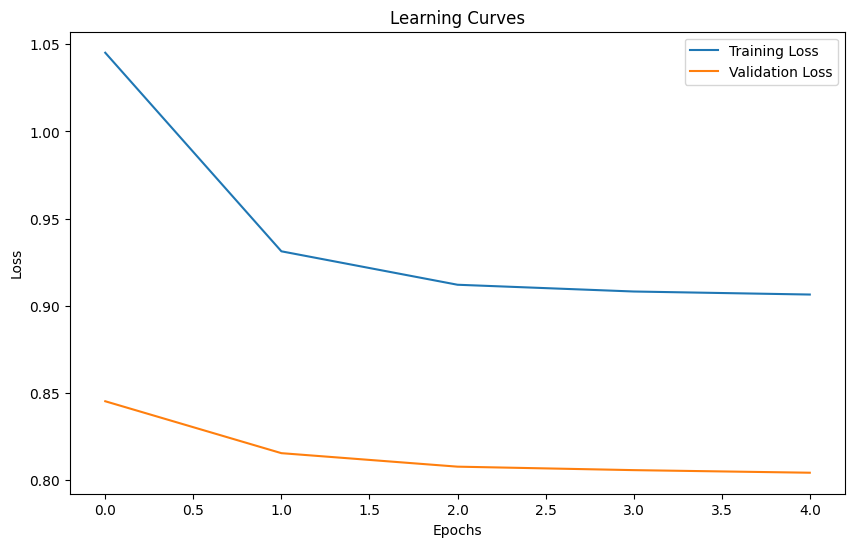

Model test_qae_model.keras saved. Size: 87.7060546875 KB
QAE model successfully trained. Execute self.quantize_autoencoder() or self.prune_and_cluster_autoencoder() when ready.


In [34]:
test_qae.train_autoencoder()

In [35]:
test_qae.quantize_autoencoder()

Model test_qae_model.tflite saved. Size: 17.7890625 KB


/opt/conda/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model test_qae_int_quant_model.tflite saved. Size: 9.2734375 KB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [36]:
test_qae.prune_and_cluster_autoencoder()

Epoch 1/2
674/674 [==============================] - 11s 8ms/step - loss: 0.9466 - val_loss: 0.8364
Epoch 2/2
674/674 [==============================] - 5s 8ms/step - loss: 0.9286 - val_loss: 0.8214
Model pruned_test_qae_model.keras saved. Size: 43.40234375 KB


/opt/conda/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


Model test_qae_pruned_model.tflite saved. Size: 9.2734375 KB
Epoch 1/10
674/674 [==============================] - 14s 14ms/step - loss: 0.9200 - val_loss: 0.8360
Epoch 2/10
674/674 [==============================] - 6s 9ms/step - loss: 0.9104 - val_loss: 0.8037
Epoch 3/10
674/674 [==============================] - 6s 9ms/step - loss: 0.9066 - val_loss: 0.8011
Epoch 4/10
674/674 [==============================] - 6s 9ms/step - loss: 0.9049 - val_loss: 0.8014
Epoch 5/10
674/674 [==============================] - 6s 9ms/step - loss: 0.9048 - val_loss: 0.8042
Epoch 6/10
674/674 [==============================] - 6s 8ms/step - loss: 0.9063 - val_loss: 0.8007
Epoch 7/10
674/674 [==============================] - 6s 9ms/step - loss: 0.9045 - val_loss: 0.8057
Epoch 8/10
674/674 [==============================] - 6s 9ms/step - loss: 0.9094 - val_loss: 0.8011
Epoch 9/10
674/674 [==============================] - 6s 9ms/step - loss: 0.9799 - val_loss: 0.8525
Epoch 10/10
674/674 [================

/opt/conda/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model test_qae_clustered_model.tflite saved. Size: 9.2734375 KB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


3848/3848 [==============================] - 6s 2ms/step


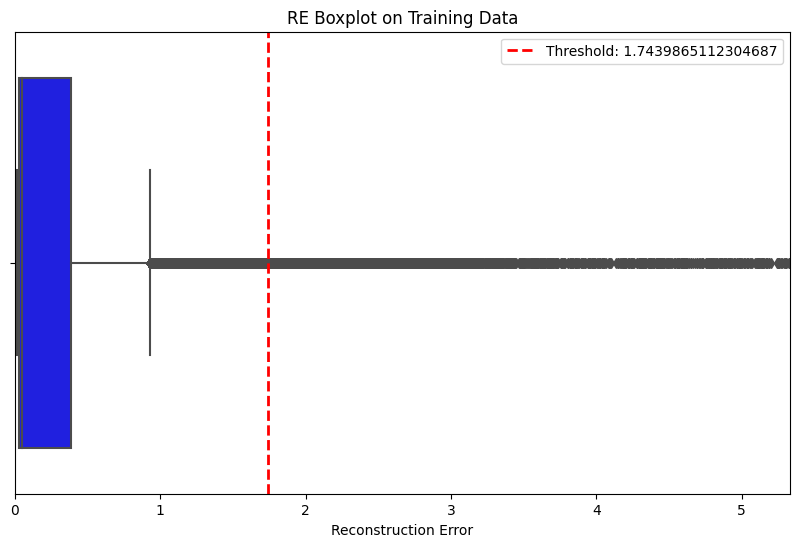

In [52]:
test_qae.test_on_validation_set("test_qae_model.keras")

<a id="s8"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>5. Test the QAE Class on the CICIoT23 Dataset</h1>
</div>

[Back to table of contents](#TOC)

## 5.1 Test the Autoencoder

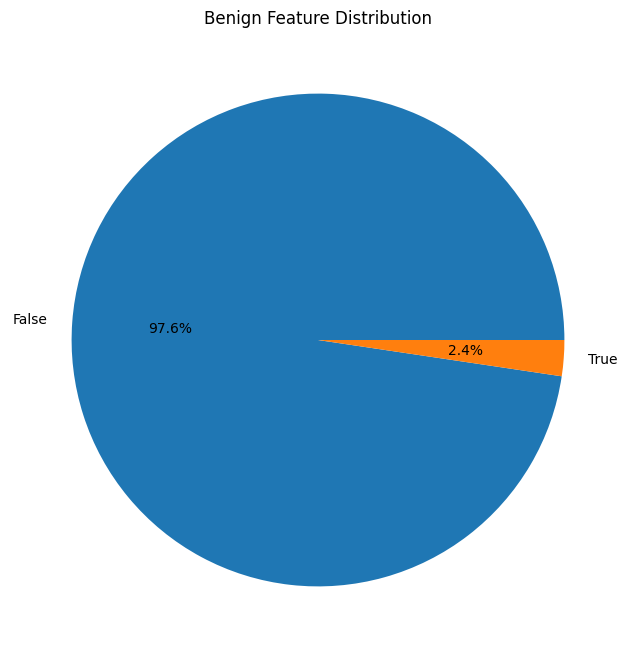

X_benign shape: (10984, 93)
X_hack shape: (455673, 93)


In [38]:
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv(LIGHT_CIC_PATH)

# Plot a circular graph over the "benign" feature distribution
plt.figure(figsize=(8, 8))
plt.pie(df['benign'].value_counts(), labels=df['benign'].value_counts().index, autopct='%1.1f%%')
plt.title('Benign Feature Distribution')
plt.show()

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Perform One-Hot Encoding of the categorical attributes
encoder = OneHotEncoder(sparse_output=False)
encoded_categorical = encoder.fit_transform(df[categorical_columns])

# Create a DataFrame for the encoded categorical features
encoded_df = pd.DataFrame(encoded_categorical, columns=encoder.get_feature_names_out(categorical_columns))

# Drop the original categorical columns and concatenate the encoded features
df = df.drop(categorical_columns, axis=1)
df = pd.concat([df, encoded_df], axis=1)

# Separate the features and the target
X = df.drop(TARGET_CIC, axis=1)
y = df[TARGET_CIC]

# Apply feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create DataFrames for the scaled features
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Isolate X_benign and X_hack from the dataset (benign and not benign data)
X_benign, y_benign = X_scaled_df[y == 1], y[y == 1]
X_hack, y_hack = X_scaled_df[y == 0], y[y == 0]

X_benign_train, X_benign_val, y_benign_train, y_benign_val = train_test_split(X_benign, y_benign, test_size=0.1, random_state=RANDOM_SEED)
X_hack_train, X_hack_val, y_hack_train, y_hack_val = train_test_split(X_hack, y_hack, test_size=0.9, random_state=RANDOM_SEED)


print("X_benign shape:", X_benign.shape)
print("X_hack shape:", X_hack.shape)

In [39]:
cic_qae = QAE(X_hack_train, y_hack_train, name="CIC_QAE_hack", models_path="", use_regularization=False, epochs=50, regularization_weights=0.1)

QAE INFO: Bottleneck layer will be made of 16 neurons.
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_22 (Dense)            (None, 128)               12032     
                                                                 
 dense_23 (Dense)            (None, 64)                8256      
                                                                 
 dense_24 (Dense)            (None, 32)                2080      
                                                                 
 dense_25 (Dense)            (None, 16)                528       
                                                                 
 dense_26 (Dense)            (None, 32)                544       
                                                                 
 dense_27 (Dense)            (None, 64)                2112      
                                                                 

Epoch 1/50
997/997 [==============================] - 8s 5ms/step - loss: 0.7426 - val_loss: 0.6419
Epoch 2/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7199 - val_loss: 0.6306
Epoch 3/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7106 - val_loss: 0.6284
Epoch 4/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7089 - val_loss: 0.6255
Epoch 5/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7101 - val_loss: 0.6279
Epoch 6/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7108 - val_loss: 0.6262
Epoch 7/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7092 - val_loss: 0.6261
Epoch 8/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7059 - val_loss: 0.6225
Epoch 9/50
997/997 [==============================] - 5s 5ms/step - loss: 0.7040 - val_loss: 0.6194
Epoch 10/50
997/997 [==============================] - 5s 5ms/step - loss: 0.6982 - val_loss: 0.6121

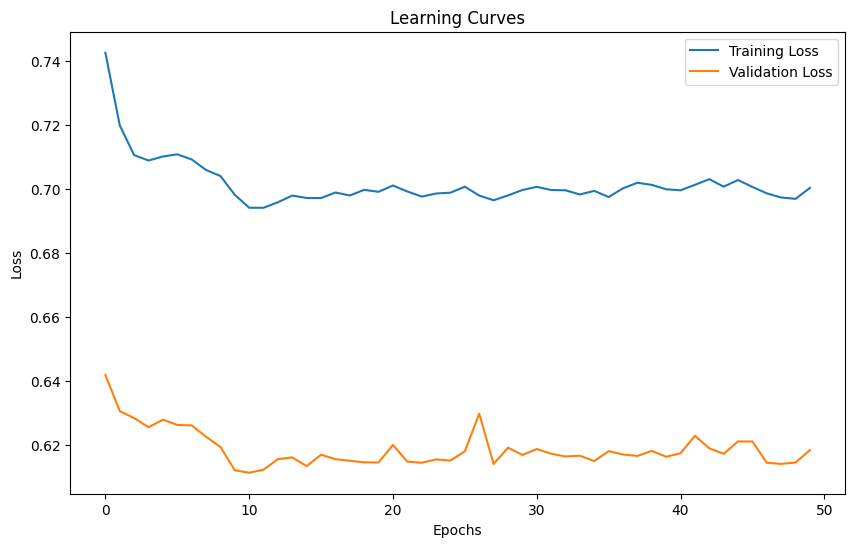

Model CIC_QAE_hack_model.keras saved. Size: 583.4990234375 KB
QAE model successfully trained. Execute self.quantize_autoencoder() or self.prune_and_cluster_autoencoder() when ready.


In [40]:
cic_qae.train_autoencoder()

1424/1424 [==============================] - 2s 2ms/step


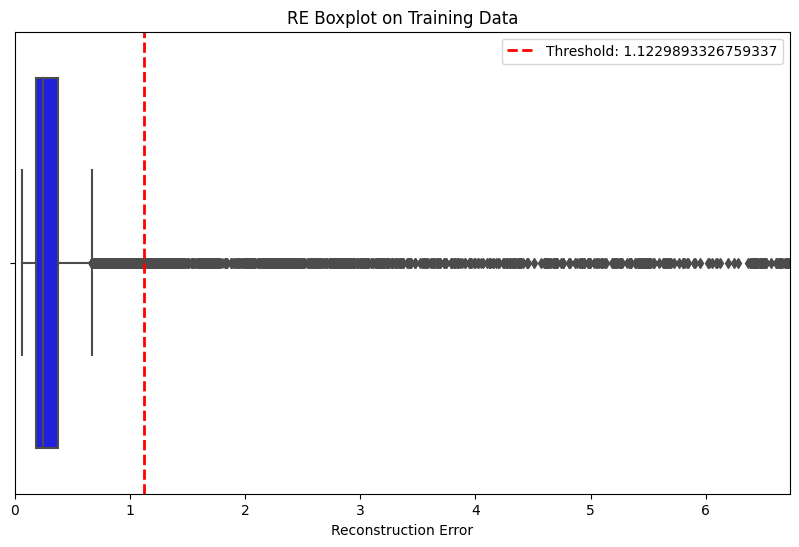

344/344 [==============================] - 1s 2ms/step


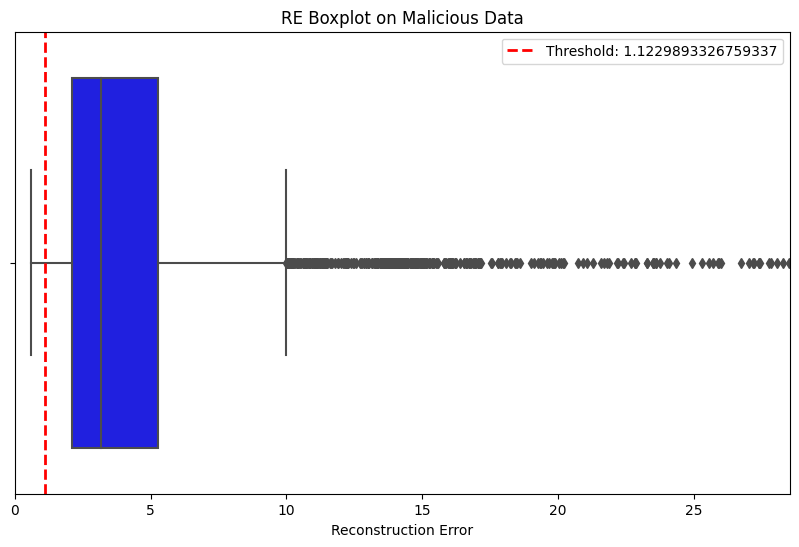

Mean reconstruction error for Malicious Data: 4.800472761088118
Percentage of anomalies detected in Malicious Data: 94.20975965040058 %
12816/12816 [==============================] - 20s 2ms/step


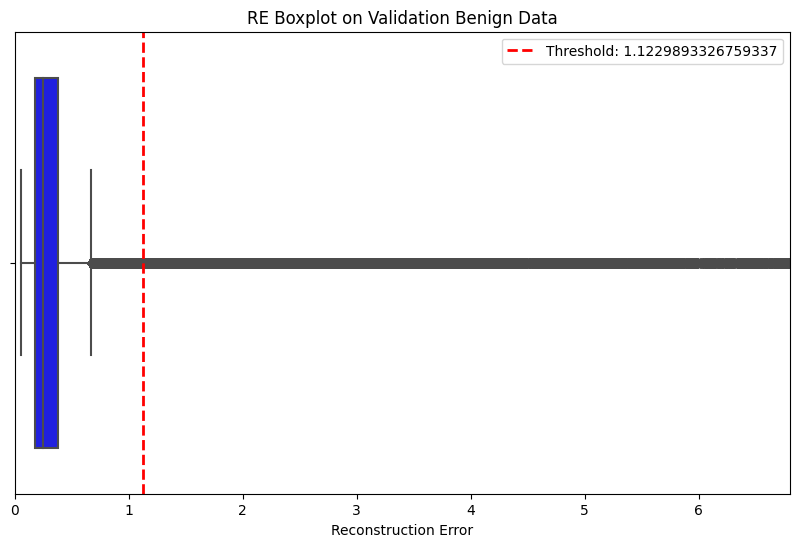

Mean reconstruction error for Validation Benign Data: 0.8352035854453261
Percentage of anomalies detected in Validation Benign Data: 4.891418316240192 %
Precision:0.9510858168375981
Recall:0.9426133999098122
F1 score:0.9468306555622017


In [53]:
cic_qae.test_on_validation_set("CIC_QAE_model.keras",X_benign_val_preprocessed=X_hack_val,X_anomaly_preprocessed=X_benign, percentage_false_negatives=0.05, automatic_threshold=False)

Very good F1-score of 94.2%!

## 5.2 Optuna

In [42]:
import optuna

# Define the objective function
def objective(trial):
    # Define the hyperparameters to be optimized
    first_layer = trial.suggest_int('first_layer', 8, 512, step=8)
    activation = trial.suggest_categorical('activation', ['relu', 'sigmoid', 'tanh'])
    optimizer = trial.suggest_categorical('optimizer', ['adam', 'sgd', 'rmsprop'])
    batch_size = trial.suggest_int('batch_size', 16, 128, step=16)
    regularization_weights = trial.suggest_float('regularization_weights', 0.0001, 0.1, log=True)
    #epochs = trial.suggest_int('epochs', 10, 100, step=5)

    # Define other parameters
    NAME = "optuna_qae"
    params = {
        'name': NAME,
        'first_layer': first_layer,
        'activation': activation,
        'optimizer': optimizer,
        'batch_size': batch_size,
        'regularization_weights': regularization_weights,
        'epochs': 20,
        'use_regularization': True,
        'verbose': False  # Set to False to reduce output during optimization
    }

    # Create and train the QAE model
    qae = QAE(X_hack_train, y_hack_train, **params)
    qae.train_autoencoder()

    # Evaluate the model on the validation set
    qae.test_on_validation_set(NAME + "_model.keras", X_benign_val_preprocessed=X_hack_val, X_anomaly_preprocessed=X_benign, percentage_false_negatives=0.01, silence=True)

    # Return the recall 
    return qae.recall

In [43]:
# Create a study object and specify the direction of optimization
study = optuna.create_study(direction='maximize')

[I 2024-07-22 15:16:20,678] A new study created in memory with name: no-name-ac09761e-f373-4a5a-8937-5b7d444c4241


In [44]:
"""
# Start the optimization process
study.optimize(objective, n_trials=100)

# Get the best parameters
best_params = study.best_params
print("Best parameters: ", best_params)
print("Best Recall: ", study.best_value)
"""

'\n# Start the optimization process\nstudy.optimize(objective, n_trials=100)\n\n# Get the best parameters\nbest_params = study.best_params\nprint("Best parameters: ", best_params)\nprint("Best Recall: ", study.best_value)\n'

Allows 100% of the benign traffic to go and stops 90% of the malicious traffic:

```[I 2024-07-18 13:15:15,416] Trial 1 finished with value: 1.0 and parameters: {'first_layer': 40, 'activation': 'tanh', 'optimizer': 'rmsprop', 'batch_size': 128, 'regularization_weights': 0.0002373931408994143}.```

97% recall:

```[I 2024-07-18 14:27:22,274] Trial 5 finished with value: 0.9733475954157229 and parameters: {'first_layer': 288, 'activation': 'tanh', 'optimizer': 'adam', 'batch_size': 112, 'regularization_weights': 0.004035483817578062, 'prec': 0.9509181090307828}.```

QAE INFO: Bottleneck layer will be made of 5 neurons.
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30 (Dense)            (None, 40)                3760      
                                                                 
 dense_31 (Dense)            (None, 20)                820       
                                                                 
 dense_32 (Dense)            (None, 10)                210       
                                                                 
 dense_33 (Dense)            (None, 5)                 55        
                                                                 
 dense_34 (Dense)            (None, 10)                60        
                                                                 
 dense_35 (Dense)            (None, 20)                220       
                                                                 


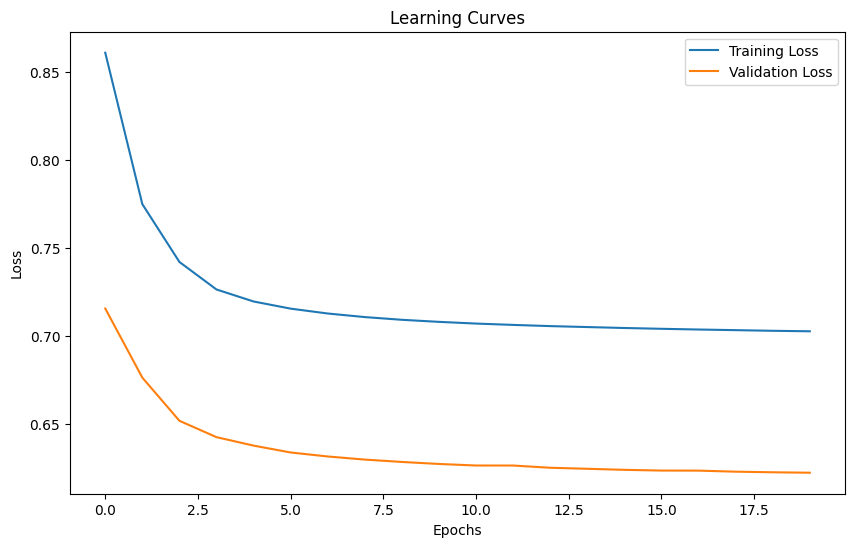

Model best_optuna_ben100.0_mal010.1_qae_model.keras saved. Size: 117.2705078125 KB
QAE model successfully trained. Execute self.quantize_autoencoder() or self.prune_and_cluster_autoencoder() when ready.
1424/1424 [==============================] - 2s 2ms/step


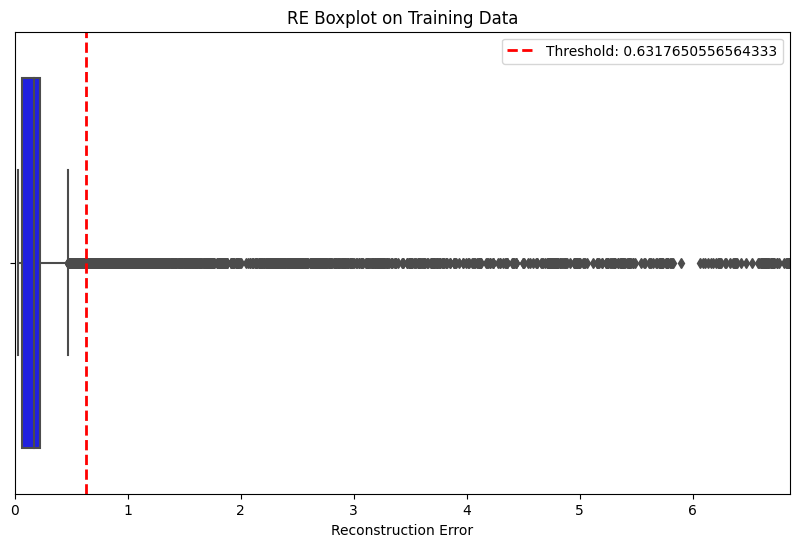

344/344 [==============================] - 1s 2ms/step


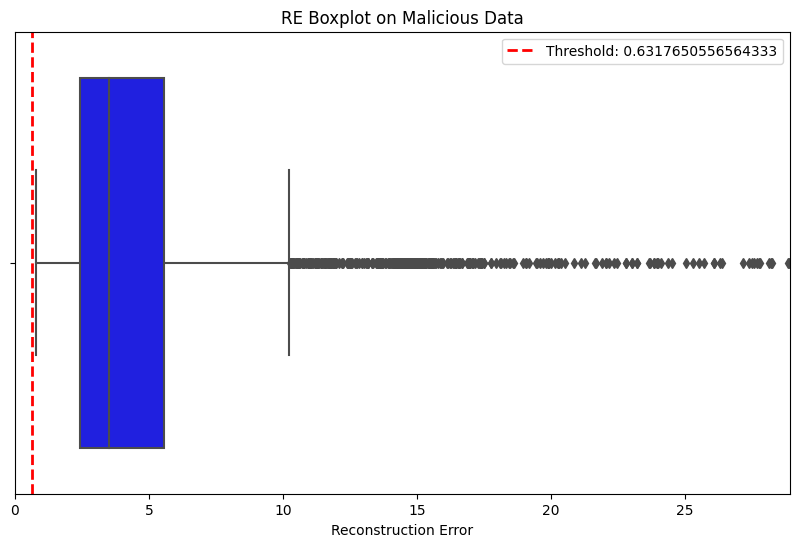

Mean reconstruction error for Malicious Data: 5.111310484319431
Percentage of anomalies detected in Malicious Data: 100.0 %
12816/12816 [==============================] - 20s 2ms/step


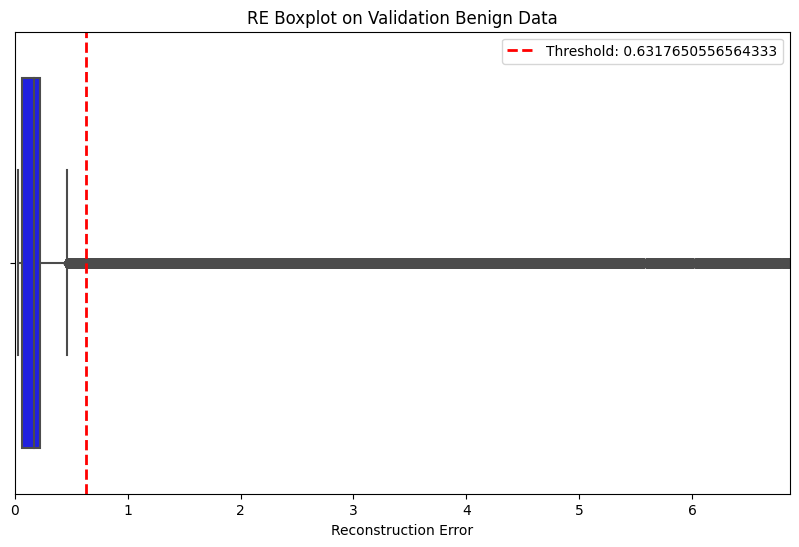

Mean reconstruction error for Validation Benign Data: 0.7297963542798827
Percentage of anomalies detected in Validation Benign Data: 9.825508527063736 %
Precision:0.9017449147293627
Recall:1.0
F1 score:0.948334245823594


In [45]:
best_params = {
    'name': "best_optuna_ben100.0_mal010.1_qae",
    'first_layer': 40,
    'activation': 'tanh',
    'optimizer': 'rmsprop',
    'batch_size': 128,
    'regularization_weights': 0.0002373931408994143,
    'epochs': 20,
    'use_regularization': True
}
optimized_qae = QAE(X_hack_train, y_hack_train, **best_params)
optimized_qae.train_autoencoder()
optimized_qae.test_on_validation_set(best_params['name'] + "_model.keras", X_benign_val_preprocessed=X_hack_val, X_anomaly_preprocessed=X_benign, percentage_false_negatives=0.10, silence=False)

QAE INFO: Bottleneck layer will be made of 36 neurons.
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_38 (Dense)            (None, 288)               27072     
                                                                 
 dense_39 (Dense)            (None, 144)               41616     
                                                                 
 dense_40 (Dense)            (None, 72)                10440     
                                                                 
 dense_41 (Dense)            (None, 36)                2628      
                                                                 
 dense_42 (Dense)            (None, 72)                2664      
                                                                 
 dense_43 (Dense)            (None, 144)               10512     
                                                                 

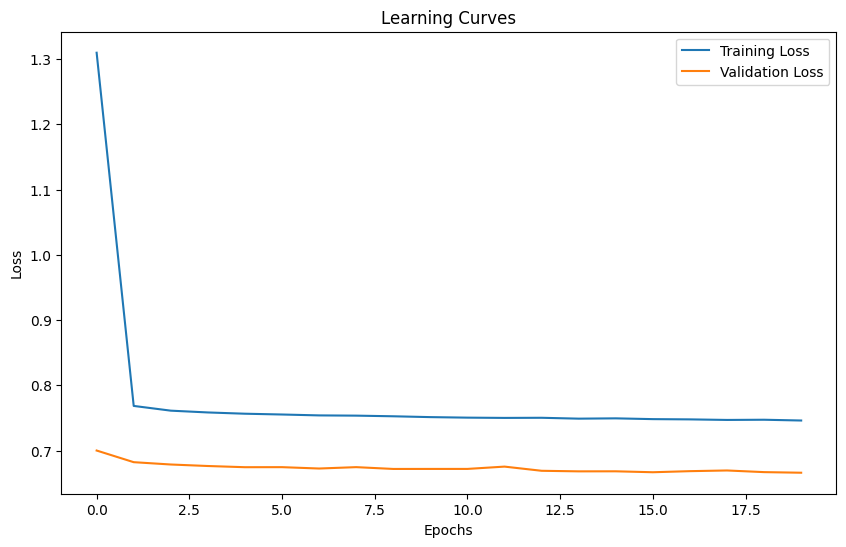

Model best_optuna_ben050.0_mal000.1_qae_model.keras saved. Size: 1963.572265625 KB
QAE model successfully trained. Execute self.quantize_autoencoder() or self.prune_and_cluster_autoencoder() when ready.
1424/1424 [==============================] - 2s 2ms/step


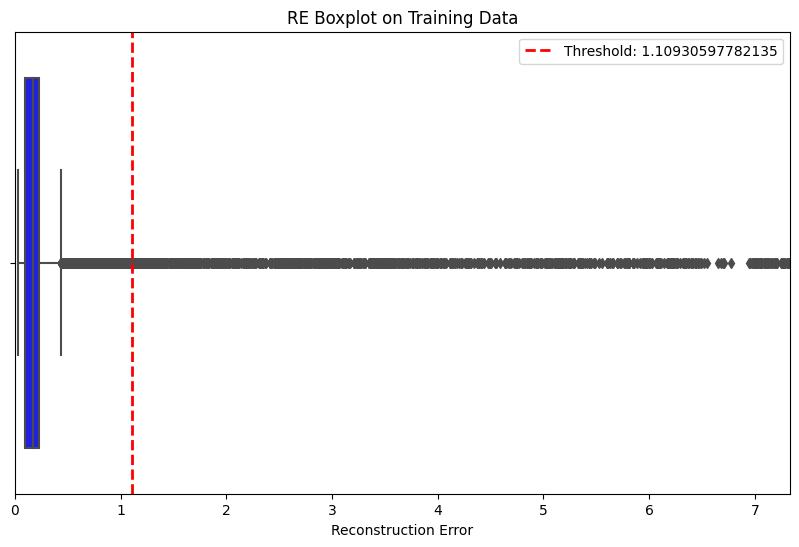

344/344 [==============================] - 1s 2ms/step


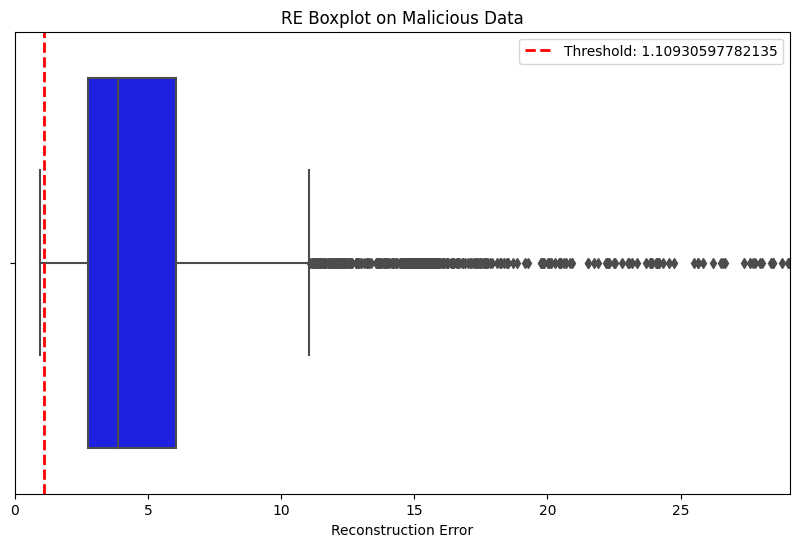

Mean reconstruction error for Malicious Data: 5.474497749790592
Percentage of anomalies detected in Malicious Data: 99.25345957756737 %
12816/12816 [==============================] - 19s 2ms/step


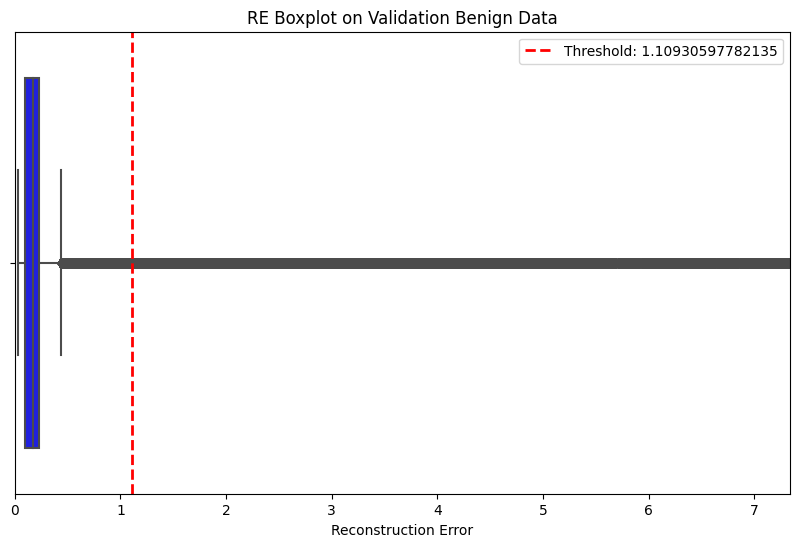

Mean reconstruction error for Validation Benign Data: 0.760845811842238
Percentage of anomalies detected in Validation Benign Data: 4.856305442983034 %
Precision:0.9514369455701697
Recall:0.9922146355925333
F1 score:0.9713980338733913


In [46]:
best_params = {
    'name': "best_optuna_ben050.0_mal000.1_qae",
    'first_layer': 288, 'activation': 'tanh', 'optimizer': 'adam', 'batch_size': 112, 'regularization_weights': 0.004035483817578062,
    'epochs': 20,
    'use_regularization': True
}
optimized_qae2 = QAE(X_hack_train, y_hack_train, **best_params)
optimized_qae2.train_autoencoder()
optimized_qae2.test_on_validation_set(best_params['name'] + "_model.keras", X_benign_val_preprocessed=X_hack_val, X_anomaly_preprocessed=X_benign, percentage_false_negatives=0.05, silence=False)

## 5.3 Quantized Model

In [47]:
optimized_qae2.quantize_autoencoder()

Model best_optuna_ben050.0_mal000.1_qae_model.tflite saved. Size: 643.79296875 KB


/opt/conda/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:887: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Model best_optuna_ben050.0_mal000.1_qae_int_quant_model.tflite saved. Size: 169.3984375 KB


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


In [48]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import precision_score, recall_score, f1_score

# Load the TFLite model and allocate tensors
interpreter = tf.lite.Interpreter(model_path="best_optuna_ben100.0_mal010.1_qae_int_quant_model.tflite")
interpreter.allocate_tensors()

# Get input and output tensors
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Function to predict using the TFLite model
def predict_tflite_model(X):
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
    predictions = []
    for i in range(X.shape[0]):
        input_data = np.expand_dims(X[i], axis=0).astype(np.uint8)  # Change to uint8
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details[0]['index'])
        predictions.append(output_data)
    return np.array(predictions).squeeze()

# Predict reconstruction for benign and malicious samples
X_benign_val_reconstructed = predict_tflite_model(X_benign_val)
X_hack_reconstructed = predict_tflite_model(X_hack)

# Calculate reconstruction errors
reconstruction_error_benign = np.mean((X_benign_val - X_benign_val_reconstructed) ** 2, axis=1)
reconstruction_error_hack = np.mean((X_hack - X_hack_reconstructed) ** 2, axis=1)

# Define a threshold for anomalies (e.g., 99th percentile of benign reconstruction errors)
threshold = np.percentile(reconstruction_error_benign, 99)

# Determine anomalies
y_true = np.concatenate([np.zeros_like(reconstruction_error_benign), np.ones_like(reconstruction_error_hack)])
y_pred = np.concatenate([reconstruction_error_benign > threshold, reconstruction_error_hack > threshold])

# Calculate precision, recall, and F1-score
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Precision: 0.9153846153846154
Recall: 0.000261152185887687
F1 Score: 0.0005221554048569228


<a id="s9"></a>
<div style="color: black; background-color: #E6E6FA; padding: 10px; border-left: 5px solid purple; border-radius: 5px;">  
    <h1>6. Comparison with Random Forest Model</h1>
</div>

[Back to table of contents](#TOC)

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
df = pd.read_csv(LIGHT_CIC_PATH)

# Drop features
unbalanced_feat = ["drate", "smtp", "irc", "telnet", "ssh", "dhcp", "arp", "ipv", "llc", "dns", 
                   "cwr_flag_number", "ece_flag_number", "rst_flag_number", "syn_flag_number"]
unclear_feat = ["protocol_type", "tot_size"]

features_to_drop = unbalanced_feat + unclear_feat
df = df.drop(columns=features_to_drop)

# Separate the target from the features
X = df.drop(columns=["benign"])  # Assuming the target column is named 'target'
y = df["benign"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Create the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standard scaling
    ('pca', PCA(n_components=0.95)),  # PCA to retain 95% of the variance
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))  # Random Forest Classifier
])

# Fit the model
pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Print detailed classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.9918
              precision    recall  f1-score   support

       False       1.00      0.99      1.00    136703
        True       0.80      0.87      0.83      3295

    accuracy                           0.99    139998
   macro avg       0.90      0.93      0.91    139998
weighted avg       0.99      0.99      0.99    139998



<div style="color: white; background-color: green; padding: 10px; border-left: 5px solid green; border-radius: 5px;">
    <h2>Conclusions</h2>
    The best model so far is qae_optimized2 with a F1 score of 97.2%, a precision of 95.1% (related to the number of attacks stopped) and a recall of 99.5% (related to the number of benign traffic passed).
    The compression still needs to be optimized. The random forest model work better and faster than the optimized autoencoder.
</div>